# `Modeling Notebook`
> A Machine Learning Approach for ICU Prediction in Confirmed COVID-19 Cases

## `02`  `Model Experiments` <a name="model"></a>

### 1-  Environment Setup <a name="environmentsetup"></a>

In [4]:
# Check Which Python Jupyter is Using
import sys
print(sys.executable)

C:\Users\Firaso\anaconda3\python.exe


In [5]:
# install package (xgboost) to the same Python that Jupyter is using
#!{sys.executable} -m pip install xgboost 

# or simply use:
# !pip install 

### 2- Load Cleaned Final Modeling-Ready Dataset <a name="load"></a>

In [7]:
import pandas as pd

# Adjust path if needed
# The file `df_model.csv` is generated during the data preparation stage (EDA Notebook)
  # and provides a leakage-aware, patient-level dataset designed for reproducible model training and evaluation.

df = pd.read_csv('../data/processed/df_model.csv')

df.shape

(385, 194)

In [8]:
df.head()

,PATIENT_VISIT_IDENTIFIER,AGE_ABOVE65,AGE_PERCENTIL,GENDER,DISEASE GROUPING 1,DISEASE GROUPING 2,DISEASE GROUPING 3,DISEASE GROUPING 4,DISEASE GROUPING 5,DISEASE GROUPING 6,...,UREA_MEAN,UREA_MIN,UREA_MAX,UREA_DIFF,DIMER_MEDIAN,DIMER_MEAN,DIMER_MIN,DIMER_MAX,DIMER_DIFF,ICU
0,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,1,90th,1,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2,0,10th,0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.836145,-0.836145,-0.836145,-1.0,-0.978029,-0.978029,-0.978029,-0.978029,-1.0,1
3,3,0,40th,1,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,4,0,10th,0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.903614,-0.903614,-0.903614,-1.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,0


##### Observation: 
* df_model.csv shape is (385.194), columns includes: 192 features pluse the "target_col" and "id_col".
* "id_col" is NOT used as a model feature but it is still useful for:
  * dataset integrity checks
  * verifying one row per patient
  * debugging and traceability
  * and future patient-level analysis
---

### 3- Preprocessing Pipeline <a name="pipeline"></a>

#### 3-1 Define Feature Types (Re-declare them cleanly for execution) <a name="features"></a>

In [79]:
categorical_cols = [
    'AGE_PERCENTIL','AGE_ABOVE65','GENDER',
    'DISEASE GROUPING 1','DISEASE GROUPING 2','DISEASE GROUPING 3',
    'DISEASE GROUPING 4','DISEASE GROUPING 5','DISEASE GROUPING 6',
    'HTN','IMMUNOCOMPROMISED','OTHER'
]

target_col = 'ICU'
id_col = 'PATIENT_VISIT_IDENTIFIER'

numeric_cols = [col for col in df.columns if col not in categorical_cols + [target_col, id_col]]

print("Total columns:",len(df.columns))
print("including: features, target, and ID columns")

print("\n------------------\n")
print("Total Features:", len([col for col in df.columns if col not in [target_col, id_col]]))
print("including:")
print("- Categorical columns:", len(categorical_cols))
print("- Numeric columns:", len(numeric_cols))


print("------------------\n")

Total columns: 194
including: features, target, and ID columns

------------------

Total Features: 192
including:
- Categorical columns: 12
- Numeric columns: 180
------------------



#### 3-2 Build Preprocessing Pipeline <a name="pipelinebuild"></a>

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

### 4- Train/Test Split <a name="split"></a>

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col, id_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((308, 192), (77, 192))

### 5- Model Training <a name="models"></a>

#### 5-1 Logistic Regression <a name="logreg"></a>

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ALBUMIN_MEDIAN',
                                                   'ALBUMIN_MEAN',
                                                   'ALBUMIN_MIN', 'ALBUMIN_MAX',
                                                   'ALBUMIN_DIFF',
                                                   'BE_ARTERIAL_MEDIAN',
                                                   'BE_ARTERIAL_MEAN',
                                                   'BE_ARTERIAL_MIN',
                                                   'BE_ARTERIAL_MAX',
                                                   'BE_ARTERIAL_DIFF',
                                                   'BE_VENOUS_MEDIAN...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['AGE_PERCENTIL',
                                                   'AGE_ABOVE65', 'GENDER',
                                                   'DISEASE GROUPING 1',
                                                   'DISEASE GROUPING 2',
                                                   'DISEASE GROUPING 3',
                                                   'DISEASE GROUPING 4',
                                                   'DISEASE GROUPING 5',
                                                   'DISEASE GROUPING 6', 'HTN',
                                                   'IMMUNOCOMPROMISED',
                                                   'OTHER'])])),
                ('model', LogisticRegression(max_iter=1000))])

#### 5-2 Random Forest <a name="rf"></a>

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ALBUMIN_MEDIAN',
                                                   'ALBUMIN_MEAN',
                                                   'ALBUMIN_MIN', 'ALBUMIN_MAX',
                                                   'ALBUMIN_DIFF',
                                                   'BE_ARTERIAL_MEDIAN',
                                                   'BE_ARTERIAL_MEAN',
                                                   'BE_ARTERIAL_MIN',
                                                   'BE_ARTERIAL_MAX',
                                                   'BE_ARTERIAL_DIFF',
                                                   'BE_VENOUS_MEDIAN...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['AGE_PERCENTIL',
                                                   'AGE_ABOVE65', 'GENDER',
                                                   'DISEASE GROUPING 1',
                                                   'DISEASE GROUPING 2',
                                                   'DISEASE GROUPING 3',
                                                   'DISEASE GROUPING 4',
                                                   'DISEASE GROUPING 5',
                                                   'DISEASE GROUPING 6', 'HTN',
                                                   'IMMUNOCOMPROMISED',
                                                   'OTHER'])])),
                ('model', RandomForestClassifier(random_state=42))])

#### 5-3 XGBoost <a name="xgb"></a>

In [22]:
from xgboost import XGBClassifier

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss'))
])

xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ALBUMIN_MEDIAN',
                                                   'ALBUMIN_MEAN',
                                                   'ALBUMIN_MIN', 'ALBUMIN_MAX',
                                                   'ALBUMIN_DIFF',
                                                   'BE_ARTERIAL_MEDIAN',
                                                   'BE_ARTERIAL_MEAN',
                                                   'BE_ARTERIAL_MIN',
                                                   'BE_ARTERIAL_MAX',
                                                   'BE_ARTERIAL_DIFF',
                                                   'BE_VENOUS_MEDIAN...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### 6- Model Evaluation <a name="evaluation"></a>

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results = {
    'Logistic Regression': evaluate(log_reg),
    'Random Forest': evaluate(rf),
    'XGBoost': evaluate(xgb)
}

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.688312,0.682927,0.717949,0.700000,0.691970
Random Forest,0.701299,0.666667,0.820513,0.735632,0.720310
XGBoost,0.649351,0.630435,0.743590,0.682353,0.737854


### 7- Model Comparison <a name="comparison"></a>

In [26]:
results_df.sort_values(by='F1', ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.701299,0.666667,0.820513,0.735632,0.720310
Logistic Regression,0.688312,0.682927,0.717949,0.700000,0.691970
XGBoost,0.649351,0.630435,0.743590,0.682353,0.737854


`Observation`

We evaluated Logistic Regression, Random Forest, and XGBoost models.

Random Forest was selected as the final model as it achieved the strongest overall performance, with the highest F1-score and ROC-AUC, and a favorable balance between recall and precision.

**Rationale:**

- Highest F1-score and ROC-AUC among all models
- Strong recall for ICU cases (~0.82), reducing false negatives, which is critical in clinical settings
- Comparable precision with fewer false positives than XGBoost
- Captures non-linear feature interactions while remaining interpretable and robust for tabular data

From a clinical perspective, minimizing false negatives (missed ICU cases) is a priority. Random Forest achieves this while maintaining stable precision, making it a suitable choice for early risk prediction.

### 8- Final Model Selection <a name="selection"></a>

Random Forest is selected based on best overall F1-score and ROC-AUC.

### 9- Feature Importance

>(what the model learned from Random Forest) <a name="importance"></a>

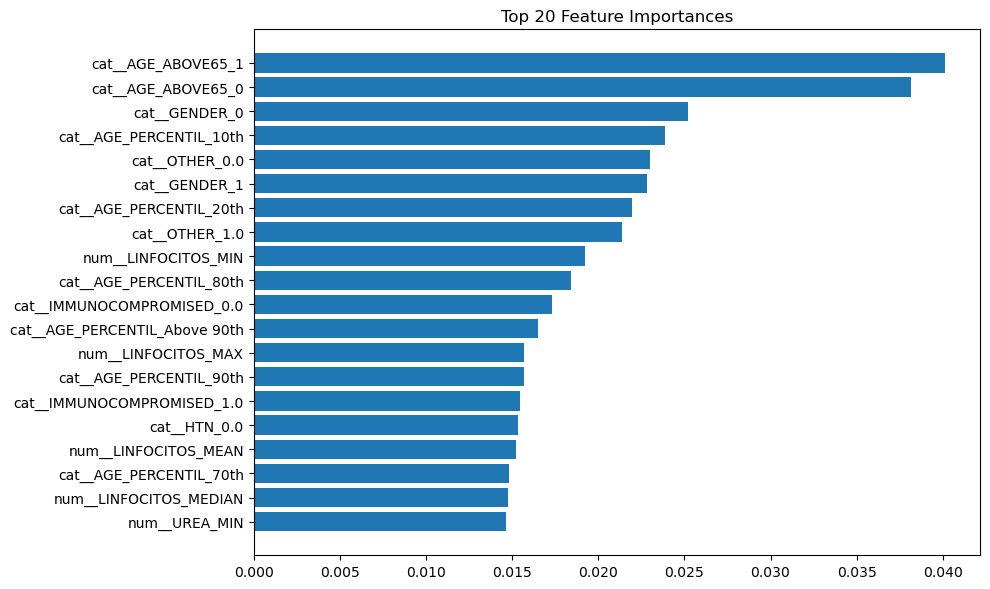

,feature,importance
191,cat__AGE_ABOVE65_1,0.040154
190,cat__AGE_ABOVE65_0,0.038141
192,cat__GENDER_0,0.025208
180,cat__AGE_PERCENTIL_10th,0.023898
210,cat__OTHER_0.0,0.023031
193,cat__GENDER_1,0.022827
181,cat__AGE_PERCENTIL_20th,0.021970
211,cat__OTHER_1.0,0.021378
87,num__LINFOCITOS_MIN,0.019239
187,cat__AGE_PERCENTIL_80th,0.018395


In [34]:
import matplotlib.pyplot as plt

rf_model = rf.named_steps['model']
feature_names = rf.named_steps['preprocessor'].get_feature_names_out()

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1])
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

feat_imp

### 10- Key Findings <a name="findings"></a>

- Random Forest achieved best performance
- Strong recall for ICU prediction
- Clinically relevant features identified (age, inflammation, blood markers)
- Early prediction strategy validated